# Hei Njål
# ***I LOVE COCK***

In [121]:
print('U lost bbygurl?')

U lost bbygurl?


Importing our dataset

In [ ]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import RFE
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
from xgboost import XGBRegressor
# from sklearn.model_selection import GridSearchCV
# from sklearn.model_selection import RandomizedSearchCV
import optuna
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
import seaborn as sns


df = pd.read_csv("../data/england-premier-league-matches-2018-to-2019-stats.csv")

Analyszing features

In [6]:
df.head()

# Identify odds-related columns
odds_columns = [col for col in df.columns if 'odds' in col.lower()]
df[odds_columns].sample()

# Identify pre-match columns
prematch_columns = [col for col in df.columns if 'pre' in col.lower() and 'match' in col.lower()]
df[prematch_columns].sample()

# Remove columns with all null values
null_columns = [col for col in df.columns if (df[col] == 0).all()]
df[null_columns].head()

# Remove incomplete matches (if any)
not_completed = [col for col in df.columns if (df['status'] != 'complete').any()]
print(not_completed)
percentage_columns = [col for col in df.columns if 'percentage' in col.lower()]
print(percentage_columns)

[]
['btts_percentage_pre_match', 'over_15_percentage_pre_match', 'over_25_percentage_pre_match', 'over_35_percentage_pre_match', 'over_45_percentage_pre_match', 'over_15_HT_FHG_percentage_pre_match', 'over_05_HT_FHG_percentage_pre_match', 'over_15_2HG_percentage_pre_match', 'over_05_2HG_percentage_pre_match']


Data cleaning

In [8]:

#Remove all columns in the dataset that include odds. 
df_filtered = df.drop(columns = odds_columns)
df_filtered = df_filtered.drop(columns = percentage_columns)

#The first match 2 matches of the season has no 'pre-match' content, but are valued at 0, which could mess with this feature
df_filtered.loc[df_filtered['Game Week'] <= 2, prematch_columns] = np.nan


# Parse date_GMT into useful features
df_filtered['match_date'] = pd.to_datetime(df_filtered['date_GMT'], errors='coerce')
df_filtered['match_month'] = df_filtered['match_date'].dt.month
df_filtered['match_day'] = df_filtered['match_date'].dt.day
df_filtered['match_weekday'] = df_filtered['match_date'].dt.weekday
df_filtered = df_filtered.drop(columns=['date_GMT', 'match_date'])

# Encode Categorical Columns
categorical_columns = ['home_team_name', 'away_team_name', 'stadium_name', 'referee']
label_encoders = {}
for col in categorical_columns:
    df_filtered[col] = df_filtered[col].fillna("Unknown")
    le = LabelEncoder()
    df_filtered[col] = le.fit_transform(df_filtered[col].astype(str))
    label_encoders[col] = le


# Drop Irrelevant or Redundant Columns
df_filtered = df_filtered.drop(columns=[
    'status', 'home_team_goal_timings', 'away_team_goal_timings', 'btts_percentage_pre_match',
    'over_15_percentage_pre_match', 'over_25_percentage_pre_match', 'over_35_percentage_pre_match',
    'over_45_percentage_pre_match', 'over_15_HT_FHG_percentage_pre_match', 'over_05_HT_FHG_percentage_pre_match',
    'over_15_2HG_percentage_pre_match', 'over_05_2HG_percentage_pre_match', 'total_goal_count',
    'home_team_goal_count_half_time', 'away_team_goal_count_half_time', 'total_goals_at_half_time'
])

#Reordering so the target features appear first in the list
# target_features = ['home_team_goal_count', 'away_team_goal_count'] 
# columns = target_features + [col for col in df_filtered.columns if col not in target_features]
# df_filtered = df_filtered[columns]

# Fill missing values only for numeric columns
numeric_columns = df_filtered.select_dtypes(include=[np.number]).columns
df_filtered[numeric_columns] = df_filtered[numeric_columns].fillna(df_filtered[numeric_columns].mean())

print(df_filtered.columns)
df_filtered.sample(5)

Index(['timestamp', 'attendance', 'home_team_name', 'away_team_name',
       'referee', 'Game Week', 'Pre-Match PPG (Home)', 'Pre-Match PPG (Away)',
       'home_ppg', 'away_ppg', 'home_team_goal_count', 'away_team_goal_count',
       'home_team_corner_count', 'away_team_corner_count',
       'home_team_yellow_cards', 'home_team_red_cards',
       'away_team_yellow_cards', 'away_team_red_cards',
       'home_team_first_half_cards', 'home_team_second_half_cards',
       'away_team_first_half_cards', 'away_team_second_half_cards',
       'home_team_shots', 'away_team_shots', 'home_team_shots_on_target',
       'away_team_shots_on_target', 'home_team_shots_off_target',
       'away_team_shots_off_target', 'home_team_fouls', 'away_team_fouls',
       'home_team_possession', 'away_team_possession',
       'Home Team Pre-Match xG', 'Away Team Pre-Match xG', 'team_a_xg',
       'team_b_xg', 'average_goals_per_match_pre_match',
       'average_corners_per_match_pre_match',
       'average_card

C:\Users\sande\AppData\Local\Temp\ipykernel_960\4159757070.py:10: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_filtered['match_date'] = pd.to_datetime(df_filtered['date_GMT'], errors='coerce')


,timestamp,attendance,home_team_name,away_team_name,referee,Game Week,Pre-Match PPG (Home),Pre-Match PPG (Away),home_ppg,away_ppg,...,Away Team Pre-Match xG,team_a_xg,team_b_xg,average_goals_per_match_pre_match,average_corners_per_match_pre_match,average_cards_per_match_pre_match,stadium_name,match_month,match_day,match_weekday
243,1549119600,40626,5,9,14,25,2.08,0.55,2.21,0.37,...,1.23,2.14,0.76,2.57,9.88,3.08,14,2,2,5
339,1555768800,59960,18,10,10,35,1.59,1.41,1.63,1.32,...,1.38,1.34,1.51,3.00,11.41,3.12,8,4,20,5
187,1545844500,30608,2,1,2,19,1.75,1.75,1.21,1.32,...,1.48,1.35,1.15,3.63,8.63,4.26,15,12,26,2
199,1546187400,74556,13,0,9,20,2.00,1.00,1.89,0.84,...,1.34,1.58,1.00,3.28,12.23,2.78,10,12,30,6
50,1537615800,23418,8,17,11,6,1.50,3.00,1.11,1.21,...,1.25,1.26,1.55,4.00,7.50,3.50,2,9,22,5


Feature Importance Testing

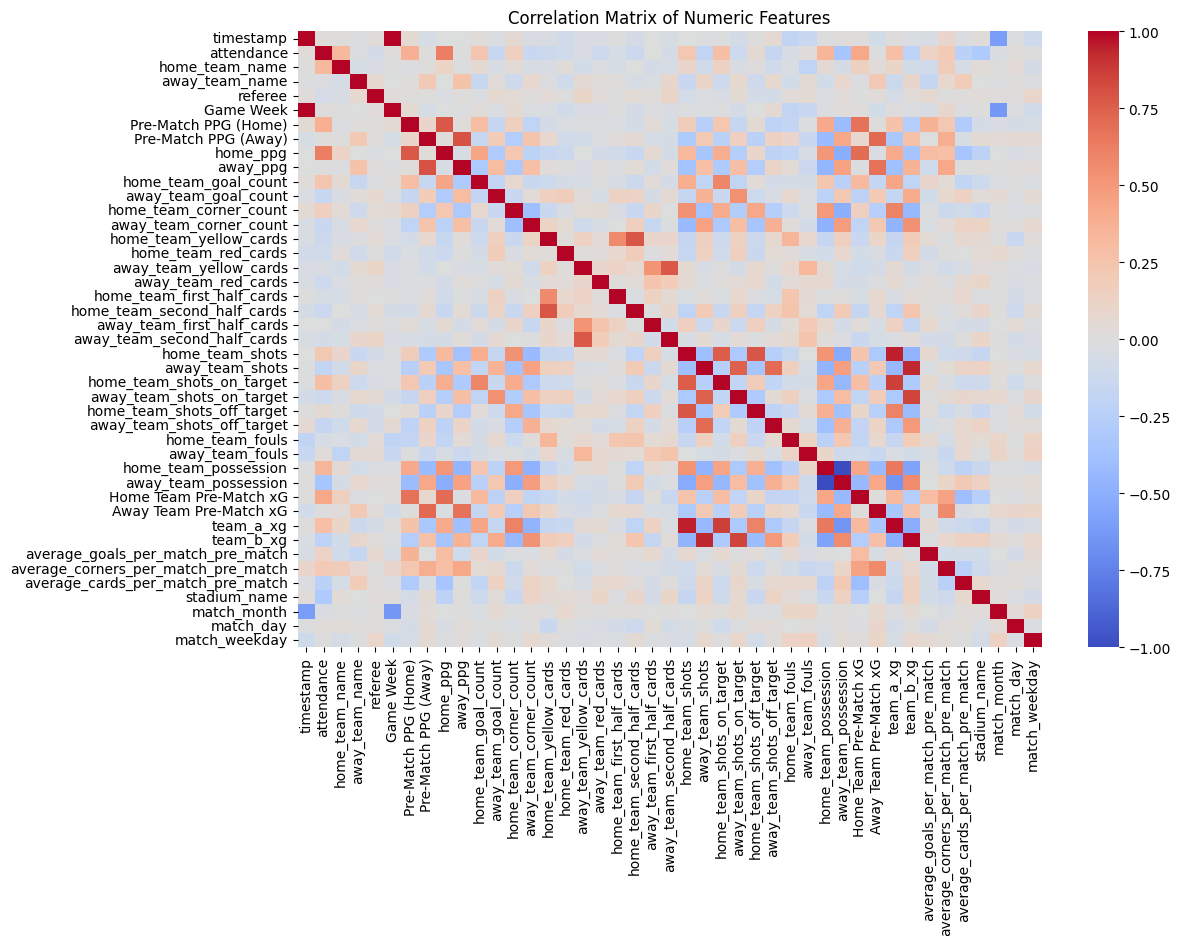

In [9]:
correlation_matrix = df_filtered.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=False, fmt=".2f", cmap="coolwarm", cbar=True)
plt.title("Correlation Matrix of Numeric Features")
plt.show()

Her kan du putte in greiene om feature optimalisering sander

Then, using the *Random Forest Regressor* we will find the feature importance


--- Home Team Scores ---
Mean Absolute Error (MAE): 0.9356578947368421
Mean Squared Error (MSE): 1.332396052631579
R^2 Score: 0.1456572380106571

--- Away Team Scores ---
Mean Absolute Error (MAE): 0.6682894736842105
Mean Squared Error (MSE): 0.7854986842105264
R^2 Score: 0.2407897590361444


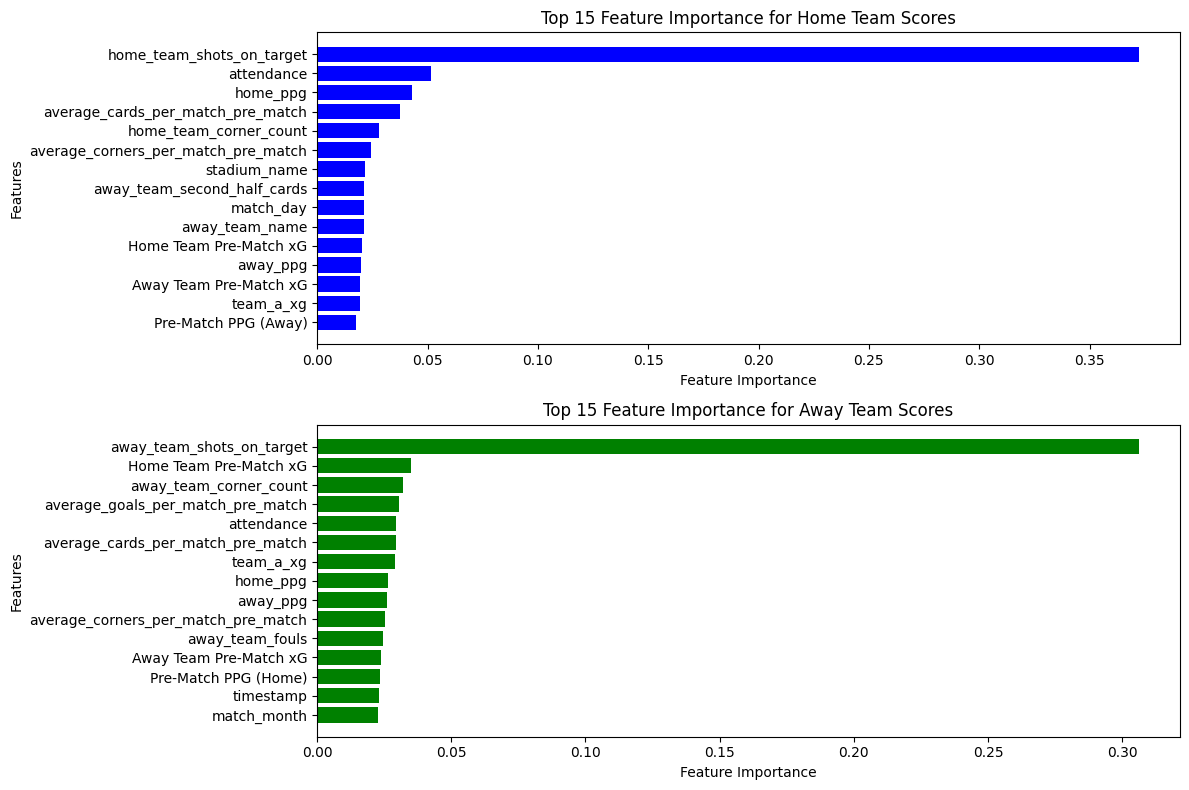

In [12]:
# Define feature and target columns
target_columns = ['home_team_goal_count', 'away_team_goal_count']
X = df_filtered.drop(columns=target_columns)
y_home = df_filtered['home_team_goal_count']
y_away = df_filtered['away_team_goal_count']

# Split dataset into train-test sets for home and away scores
X_train_home, X_test_home, y_train_home, y_test_home = train_test_split(X, y_home, test_size=0.2, random_state=42)
X_train_away, X_test_away, y_train_away, y_test_away = train_test_split(X, y_away, test_size=0.2, random_state=42)

# Train Random Forest models for home and away scores
rf_home = RandomForestRegressor(random_state=42)
rf_home.fit(X_train_home, y_train_home)

rf_away = RandomForestRegressor(random_state=42)
rf_away.fit(X_train_away, y_train_away)

# Extract feature importance for home and away scores
importances_home = rf_home.feature_importances_
importances_away = rf_away.feature_importances_

feature_importance_home_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances_home})
feature_importance_away_df = pd.DataFrame({'Feature': X.columns, 'Importance': importances_away})

feature_importance_home_df.sort_values(by='Importance', ascending=False, inplace=True)
feature_importance_away_df.sort_values(by='Importance', ascending=False, inplace=True)

# Evaluate models on test data
y_pred_home = rf_home.predict(X_test_home)
y_pred_away = rf_away.predict(X_test_away)

# Metrics for Home Scores
print("\n--- Home Team Scores ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_home, y_pred_home)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_home, y_pred_home)}")
print(f"R^2 Score: {r2_score(y_test_home, y_pred_home)}")

# Metrics for Away Scores
print("\n--- Away Team Scores ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_away, y_pred_away)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_away, y_pred_away)}")
print(f"R^2 Score: {r2_score(y_test_away, y_pred_away)}")

# Visualize Top Features
top_n = 15  # Number of features to display
top_features_home = feature_importance_home_df.head(top_n)
top_features_away = feature_importance_away_df.head(top_n)

# Top features home team
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.barh(top_features_home['Feature'], top_features_home['Importance'], color='blue')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title(f'Top {top_n} Feature Importance for Home Team Scores')
plt.gca().invert_yaxis()

# Top features away team
plt.subplot(2, 1, 2)
plt.barh(top_features_away['Feature'], top_features_away['Importance'], color='green')
plt.xlabel('Feature Importance')
plt.ylabel('Features')
plt.title(f'Top {top_n} Feature Importance for Away Team Scores')
plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

Then we use *Recursive Feature Elimination* to select which features to carry on using. We will then have a list of features optimized for each score. We will use this to make better models, one for each score, and then we will try a MultiRegressor to compare how they perform.

In [16]:
# Recursive Feature Elimination (RFE) for Home Team Scores
rfe_home = RFE(estimator=rf_home, n_features_to_select=10)
rfe_home.fit(X_train_home, y_train_home)
selected_features_home = X.columns[rfe_home.support_]

# Recursive Feature Elimination (RFE) for Away Team Scores
rfe_away = RFE(estimator=rf_away, n_features_to_select=10)
rfe_away.fit(X_train_away, y_train_away)
selected_features_away = X.columns[rfe_away.support_]

# Print selected features
print("Selected Features for Home Team Scores using RFE:", selected_features_home)
print("Selected Features for Away Team Scores using RFE:", selected_features_away)

# Train New Models on RFE-Selected Features
rf_home_rfe = RandomForestRegressor(random_state=42)
rf_away_rfe = RandomForestRegressor(random_state=42)

rf_home_rfe.fit(X_train_home[selected_features_home], y_train_home)
rf_away_rfe.fit(X_train_away[selected_features_away], y_train_away)

# Predictions with RFE-Selected Features
y_pred_home_rfe = rf_home_rfe.predict(X_test_home[selected_features_home])
y_pred_away_rfe = rf_away_rfe.predict(X_test_away[selected_features_away])

# Evaluate RFE Models
print("\n--- Home Team Scores (RFE Model) ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_home, y_pred_home_rfe)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_home, y_pred_home_rfe)}")
print(f"R^2 Score: {r2_score(y_test_home, y_pred_home_rfe)}")

print("\n--- Away Team Scores (RFE Model) ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_away, y_pred_away_rfe)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_away, y_pred_away_rfe)}")
print(f"R^2 Score: {r2_score(y_test_away, y_pred_away_rfe)}")

Selected Features for Home Team Scores using RFE: Index(['timestamp', 'attendance', 'home_ppg', 'away_ppg',
       'home_team_corner_count', 'home_team_shots_on_target', 'team_a_xg',
       'team_b_xg', 'average_corners_per_match_pre_match',
       'average_cards_per_match_pre_match'],
      dtype='object')
Selected Features for Away Team Scores using RFE: Index(['timestamp', 'attendance', 'away_team_shots_on_target',
       'away_team_fouls', 'away_team_possession', 'Home Team Pre-Match xG',
       'team_a_xg', 'average_goals_per_match_pre_match',
       'average_corners_per_match_pre_match',
       'average_cards_per_match_pre_match'],
      dtype='object')

--- Home Team Scores (RFE Model) ---
Mean Absolute Error (MAE): 0.9315789473684211
Mean Squared Error (MSE): 1.3656947368421055
R^2 Score: 0.12430586145648292

--- Away Team Scores (RFE Model) ---
Mean Absolute Error (MAE): 0.7390789473684211
Mean Squared Error (MSE): 0.9439802631578946
R^2 Score: 0.08761211512717537


 Visualizing the difference in the **Random Forest Regressor* models with and without **RFE** features:

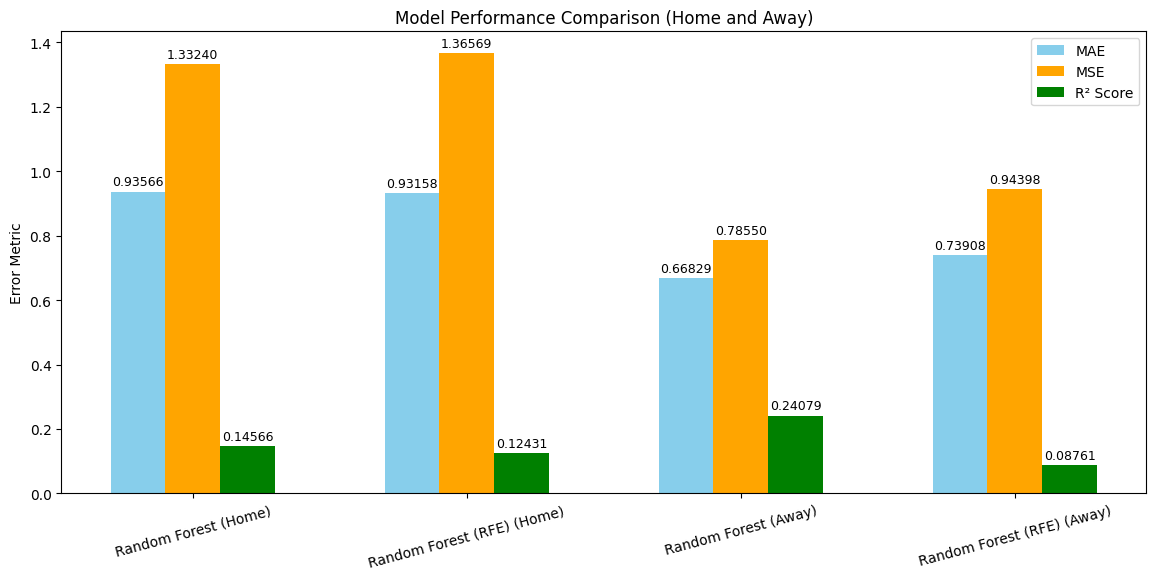

In [28]:
# Update models list to include home and away
models = ['Random Forest (Home)', 'Random Forest (RFE) (Home)', 
          'Random Forest (Away)', 'Random Forest (RFE) (Away)']
x = np.arange(len(models))  # Update x-axis positions

# Metrics (update these with your actual values)
mae = [
    mean_absolute_error(y_test_home, rf_home.predict(X_test_home)),  # Home MAE
    mean_absolute_error(y_test_home, y_pred_home_rfe),              # Home RFE MAE
    mean_absolute_error(y_test_away, rf_away.predict(X_test_away)),  # Away MAE
    mean_absolute_error(y_test_away, y_pred_away_rfe)               # Away RFE MAE
]
mse = [
    mean_squared_error(y_test_home, rf_home.predict(X_test_home)),
    mean_squared_error(y_test_home, y_pred_home_rfe),
    mean_squared_error(y_test_away, rf_away.predict(X_test_away)),
    mean_squared_error(y_test_away, y_pred_away_rfe)
]
r2 = [
    r2_score(y_test_home, rf_home.predict(X_test_home)),
    r2_score(y_test_home, y_pred_home_rfe),
    r2_score(y_test_away, rf_away.predict(X_test_away)),
    r2_score(y_test_away, y_pred_away_rfe)
]

# Plot updated metrics
plt.figure(figsize=(14, 6))
plt.bar(x - 0.2, mae, 0.2, label='MAE', color='skyblue')
plt.bar(x, mse, 0.2, label='MSE', color='orange')
plt.bar(x + 0.2, r2, 0.2, label='R² Score', color='green')

# Add annotations
for i, (mae_val, mse_val, r2_val) in enumerate(zip(mae, mse, r2)):
    plt.text(x[i] - 0.2, mae_val + 0.02, f'{mae_val:.5f}', ha='center', fontsize=9)
    plt.text(x[i], mse_val + 0.02, f'{mse_val:.5f}', ha='center', fontsize=9)
    plt.text(x[i] + 0.2, r2_val + 0.02, f'{r2_val:.5f}', ha='center', fontsize=9)

plt.xticks(x, models, rotation=15)  # Rotate labels for better readability
plt.ylabel('Error Metric')
plt.title('Model Performance Comparison (Home and Away)')
plt.legend()
plt.show()


### Using Gradient Boosting for Improved Performance
Gradient Boosting methods like XGBoost (eXtreme Gradient Boosting) often outperform Random Forest for structured/tabular data because:

- It optimizes each decision tree sequentially to reduce errors.
- It provides finer control over regularization and learning rates.

XGBoost is a machine learning algorithm based on gradient boosting, which builds decision trees sequentially to correct errors made by previous trees. It’s known for its speed, accuracy, and scalability.
- Boosting: Combines multiple weak models (trees) into a strong model.
- Gradient Descent: Optimizes the model by minimizing a loss function (e.g., Mean Squared Error).
- Regularization: Prevents overfitting using techniques like gamma and lambda.
- Efficiency: Parallel processing and optimized memory usage make it fast and scalable.
- High performance for structured/tabular data.
- Flexibility to handle regression, classification, and ranking tasks.
- Handles missing values automatically.

In [32]:
# Use RFE-selected features
X_train_home_rfe = X_train_home[selected_features_home]
X_test_home_rfe = X_test_home[selected_features_home]

X_train_away_rfe = X_train_away[selected_features_away]
X_test_away_rfe = X_test_away[selected_features_away]

# Initialize XGBoost models
xgb_home = XGBRegressor(objective='reg:squarederror', random_state=42)
xgb_away = XGBRegressor(objective='reg:squarederror', random_state=42)

# Train models
xgb_home.fit(X_train_home_rfe, y_train_home)
xgb_away.fit(X_train_away_rfe, y_train_away)

# Make predictions
y_pred_home_xgb = xgb_home.predict(X_test_home_rfe)
y_pred_away_xgb = xgb_away.predict(X_test_away_rfe)

# Evaluate models
print("\n--- Home Team Scores (XGBoost) ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_home, y_pred_home_xgb)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_home, y_pred_home_xgb)}")
print(f"R^2 Score: {r2_score(y_test_home, y_pred_home_xgb)}")

print("\n--- Away Team Scores (XGBoost) ---")
print(f"Mean Absolute Error (MAE): {mean_absolute_error(y_test_away, y_pred_away_xgb)}")
print(f"Mean Squared Error (MSE): {mean_squared_error(y_test_away, y_pred_away_xgb)}")
print(f"R^2 Score: {r2_score(y_test_away, y_pred_away_xgb)}")


--- Home Team Scores (XGBoost) ---
Mean Absolute Error (MAE): 0.9296326637268066
Mean Squared Error (MSE): 1.430367112159729
R^2 Score: 0.08283740282058716

--- Away Team Scores (XGBoost) ---
Mean Absolute Error (MAE): 0.8328273892402649
Mean Squared Error (MSE): 1.258426308631897
R^2 Score: -0.2163102626800537


## Hyper Parameter + XGBoost

#### XGBoost
- XGBoost handles both numerical features and large datasets efficiently.
- Tuning ensures the model balances accuracy and generalization.
- Results are often superior to untuned models, as hyperparameters like learning_rate and max_depth are key to performance.

#### Hyper Parameter Tuning
- Improve Accuracy: Tuning ensures the model makes more accurate score predictions by finding the best combination of parameters.
- Prevent Overfitting: Optimized parameters help the model generalize better to unseen matches.
- Model Efficiency: Avoid unnecessary complexity and reduce computational time with optimal hyperparameter choices.


In [35]:
# # Define the objective function for optimization
# def objective(trial):
#     params = {
#         'n_estimators': trial.suggest_int('n_estimators', 50, 200),
#         'max_depth': trial.suggest_int('max_depth', 2, 6),
#         'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
#         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
#         'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
#     }
#     model = XGBRegressor(objective='reg:squarederror', random_state=42, **params)
#     model.fit(X_train_home_rfe, y_train_home)
#     y_pred = model.predict(X_test_home_rfe)
#     return mean_squared_error(y_test_home, y_pred)

# # Run the optimization
# study = optuna.create_study(direction="minimize")
# study.optimize(objective, n_trials=50)

# # Best parameters
# # print("Best parameters:", study.best_params)

# # Train final XGBoost model with best parameters from Optuna
# best_params = study.best_params
# final_xgb_model = XGBRegressor(objective='reg:squarederror', random_state=42, **best_params)
# final_xgb_model.fit(X_train_home_rfe, y_train_home)

# # Make predictions
# y_pred_home_optuna = final_xgb_model.predict(X_test_home_rfe)

# Define the objective function for optimization (Home Team)
def objective_home(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
    }
    model = XGBRegressor(objective='reg:squarederror', random_state=42, **params)
    model.fit(X_train_home_rfe, y_train_home)
    y_pred = model.predict(X_test_home_rfe)
    return mean_squared_error(y_test_home, y_pred)

# Run the optimization for Home Team
study_home = optuna.create_study(direction="minimize")
study_home.optimize(objective_home, n_trials=50)

# Best parameters for Home Team
best_params_home = study_home.best_params
final_xgb_model_home = XGBRegressor(objective='reg:squarederror', random_state=42, **best_params_home)
final_xgb_model_home.fit(X_train_home_rfe, y_train_home)

# Make predictions for Home Team
y_pred_home_optuna = final_xgb_model_home.predict(X_test_home_rfe)

# Define the objective function for optimization (Away Team)
def objective_away(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 200),
        'max_depth': trial.suggest_int('max_depth', 2, 6),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 5),
    }
    model = XGBRegressor(objective='reg:squarederror', random_state=42, **params)
    model.fit(X_train_away_rfe, y_train_away)
    y_pred = model.predict(X_test_away_rfe)
    return mean_squared_error(y_test_away, y_pred)

# Run the optimization for Away Team
study_away = optuna.create_study(direction="minimize")
study_away.optimize(objective_away, n_trials=50)

# Best parameters for Away Team
best_params_away = study_away.best_params
final_xgb_model_away = XGBRegressor(objective='reg:squarederror', random_state=42, **best_params_away)
final_xgb_model_away.fit(X_train_away_rfe, y_train_away)

# Make predictions for Away Team
y_pred_away_optuna = final_xgb_model_away.predict(X_test_away_rfe)


[I 2024-12-19 20:33:01,792] A new study created in memory with name: no-name-86ee4b8c-8d3a-4ab4-9af0-fb9844215ae4
[I 2024-12-19 20:33:01,857] Trial 0 finished with value: 1.3700411319732666 and parameters: {'n_estimators': 63, 'max_depth': 5, 'learning_rate': 0.052124008480246835, 'subsample': 0.6053067717494475, 'min_child_weight': 5}. Best is trial 0 with value: 1.3700411319732666.
[I 2024-12-19 20:33:01,931] Trial 1 finished with value: 1.352148413658142 and parameters: {'n_estimators': 125, 'max_depth': 4, 'learning_rate': 0.08198961045857697, 'subsample': 0.7635955727027846, 'min_child_weight': 3}. Best is trial 1 with value: 1.352148413658142.
[I 2024-12-19 20:33:02,031] Trial 2 finished with value: 1.3822575807571411 and parameters: {'n_estimators': 113, 'max_depth': 6, 'learning_rate': 0.05837630293406426, 'subsample': 0.9484875792885873, 'min_child_weight': 4}. Best is trial 1 with value: 1.352148413658142.
[I 2024-12-19 20:33:02,186] Trial 3 finished with value: 1.40900707244

### Comparing XGBoost with and without tuning Hyper Parameters

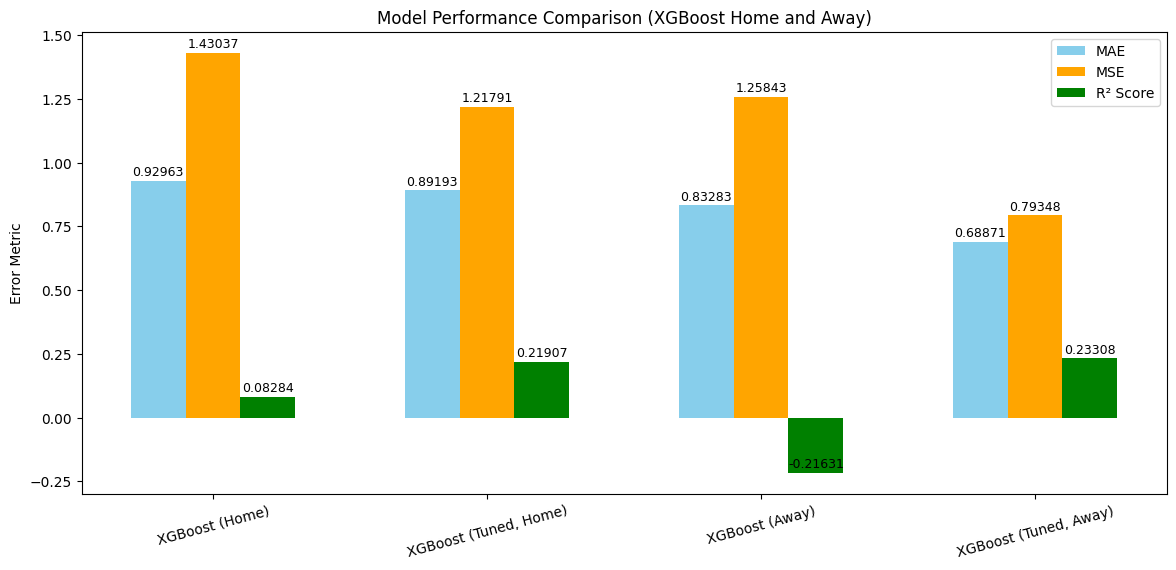

In [39]:
# # Define error metrics for comparison
# models = ['Random Forest', 'Random Forest (RFE)', 'XGBoost', 'XGBoost (Tuned)']
# mae = [
#     mean_absolute_error(y_test_home, rf_home.predict(X_test_home)),
#     mean_absolute_error(y_test_home, y_pred_home_rfe),
#     mean_absolute_error(y_test_home, y_pred_home_xgb),
#     mean_absolute_error(y_test_home, y_pred_home_optuna)
# ]
# mse = [
#     mean_squared_error(y_test_home, rf_home.predict(X_test_home)),
#     mean_squared_error(y_test_home, y_pred_home_rfe),
#     mean_squared_error(y_test_home, y_pred_home_xgb),
#     mean_squared_error(y_test_home, y_pred_home_optuna)
# ]
# r2 = [
#     r2_score(y_test_home, rf_home.predict(X_test_home)),
#     r2_score(y_test_home, y_pred_home_rfe),
#     r2_score(y_test_home, y_pred_home_xgb),
#     r2_score(y_test_home, y_pred_home_optuna)
# ]

# x = np.arange(len(models))

# # Plot Comparison of Metrics
# plt.figure(figsize=(12, 6))
# plt.bar(x - 0.2, mae, 0.2, label='MAE', color='skyblue')
# plt.bar(x, mse, 0.2, label='MSE', color='orange')
# plt.bar(x + 0.2, r2, 0.2, label='R² Score', color='green')

# plt.xticks(x, models)
# plt.ylabel('Error Metric')
# plt.title('Model Performance Comparison for Home Team')
# plt.legend()
# plt.show()

# Define updated models list for comparison
models = [
    'XGBoost (Home)', 'XGBoost (Tuned, Home)',
    'XGBoost (Away)', 'XGBoost (Tuned, Away)'
]
x = np.arange(len(models))  # Update x-axis positions

# Metrics (update these with your actual values)
mae = [
    mean_absolute_error(y_test_home, y_pred_home_xgb),          # Home XGBoost MAE
    mean_absolute_error(y_test_home, y_pred_home_optuna),      # Tuned Home XGBoost MAE
    mean_absolute_error(y_test_away, y_pred_away_xgb),         # Away XGBoost MAE
    mean_absolute_error(y_test_away, y_pred_away_optuna)       # Tuned Away XGBoost MAE
]
mse = [
    mean_squared_error(y_test_home, y_pred_home_xgb),          # Home XGBoost MSE
    mean_squared_error(y_test_home, y_pred_home_optuna),       # Tuned Home XGBoost MSE
    mean_squared_error(y_test_away, y_pred_away_xgb),          # Away XGBoost MSE
    mean_squared_error(y_test_away, y_pred_away_optuna)        # Tuned Away XGBoost MSE
]
r2 = [
    r2_score(y_test_home, y_pred_home_xgb),                    # Home XGBoost R2
    r2_score(y_test_home, y_pred_home_optuna),                 # Tuned Home XGBoost R2
    r2_score(y_test_away, y_pred_away_xgb),                    # Away XGBoost R2
    r2_score(y_test_away, y_pred_away_optuna)                  # Tuned Away XGBoost R2
]

# Plot updated metrics
plt.figure(figsize=(14, 6))
plt.bar(x - 0.2, mae, 0.2, label='MAE', color='skyblue')
plt.bar(x, mse, 0.2, label='MSE', color='orange')
plt.bar(x + 0.2, r2, 0.2, label='R² Score', color='green')

# Add annotations for each bar
for i, (mae_val, mse_val, r2_val) in enumerate(zip(mae, mse, r2)):
    plt.text(x[i] - 0.2, mae_val + 0.02, f'{mae_val:.5f}', ha='center', fontsize=9)
    plt.text(x[i], mse_val + 0.02, f'{mse_val:.5f}', ha='center', fontsize=9)
    plt.text(x[i] + 0.2, r2_val + 0.02, f'{r2_val:.5f}', ha='center', fontsize=9)

# Add labels, title, and legend
plt.xticks(x, models, rotation=15)  # Rotate labels for better readability
plt.ylabel('Error Metric')
plt.title('Model Performance Comparison (XGBoost Home and Away)')
plt.legend()
plt.show()


C:\Users\sande\AppData\Local\Temp\ipykernel_960\338869094.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


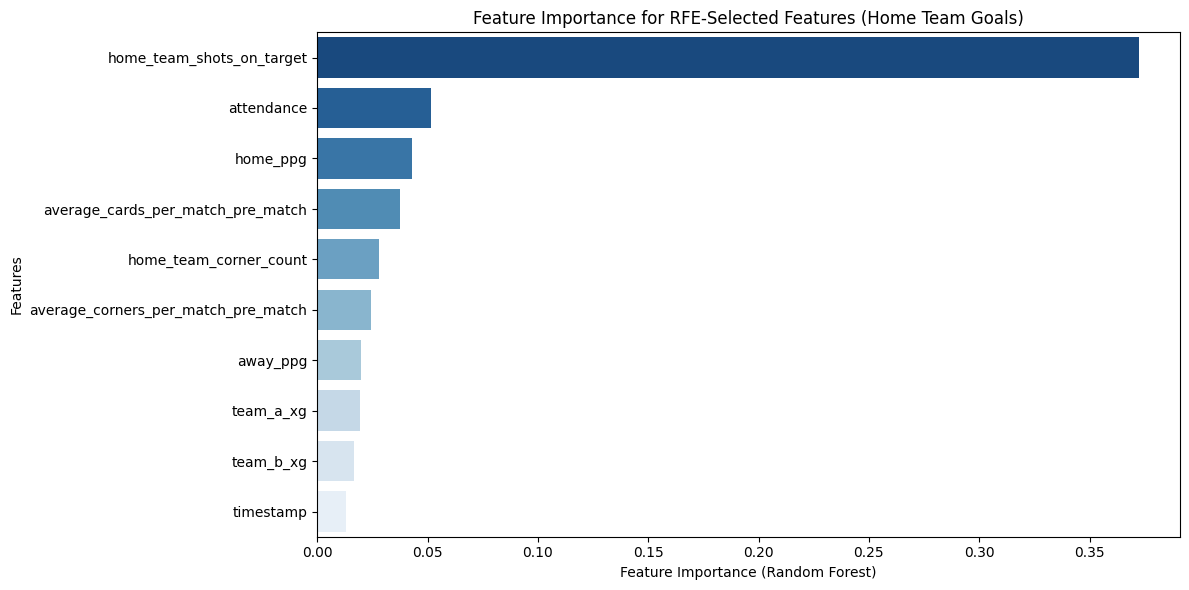

C:\Users\sande\AppData\Local\Temp\ipykernel_960\338869094.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


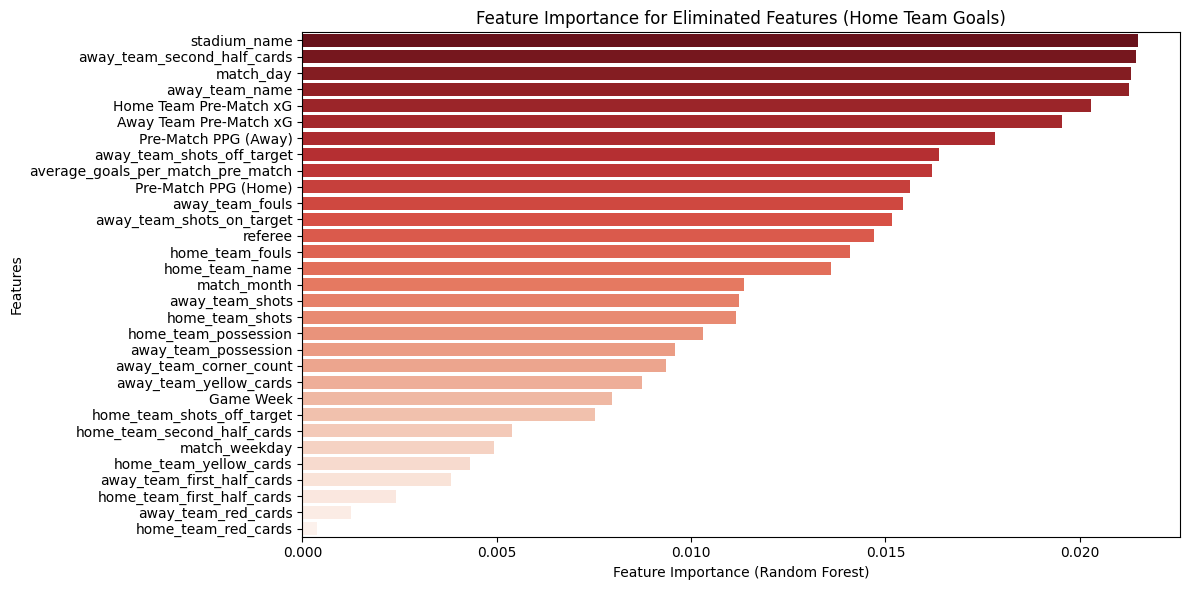

In [30]:
# Create DataFrame for RFE-selected features
selected_feature_importance = feature_importance_full[
    feature_importance_full['Feature'].isin(selected_features_home)
].sort_values(by='Importance', ascending=False)

selected_feature_importance['Correlation'] = selected_feature_importance['Feature'].map(
    df_filtered[selected_features_home].corrwith(df_filtered['home_team_goal_count'])
)

# Plot for RFE-selected features
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=selected_feature_importance,
    palette='Blues_r'
)
plt.title('Feature Importance for RFE-Selected Features (Home Team Goals)')
plt.xlabel('Feature Importance (Random Forest)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

# Create DataFrame for eliminated features
eliminated_feature_importance = feature_importance_full[
    feature_importance_full['Feature'].isin(eliminated_features)
].sort_values(by='Importance', ascending=False)

eliminated_feature_importance['Correlation'] = eliminated_feature_importance['Feature'].map(
    df_filtered[eliminated_features].corrwith(df_filtered['home_team_goal_count'])
)

# Plot for eliminated features
plt.figure(figsize=(12, 6))
sns.barplot(
    x='Importance',
    y='Feature',
    data=eliminated_feature_importance,
    palette='Reds_r'
)
plt.title('Feature Importance for Eliminated Features (Home Team Goals)')
plt.xlabel('Feature Importance (Random Forest)')
plt.ylabel('Features')
plt.tight_layout()
plt.show()


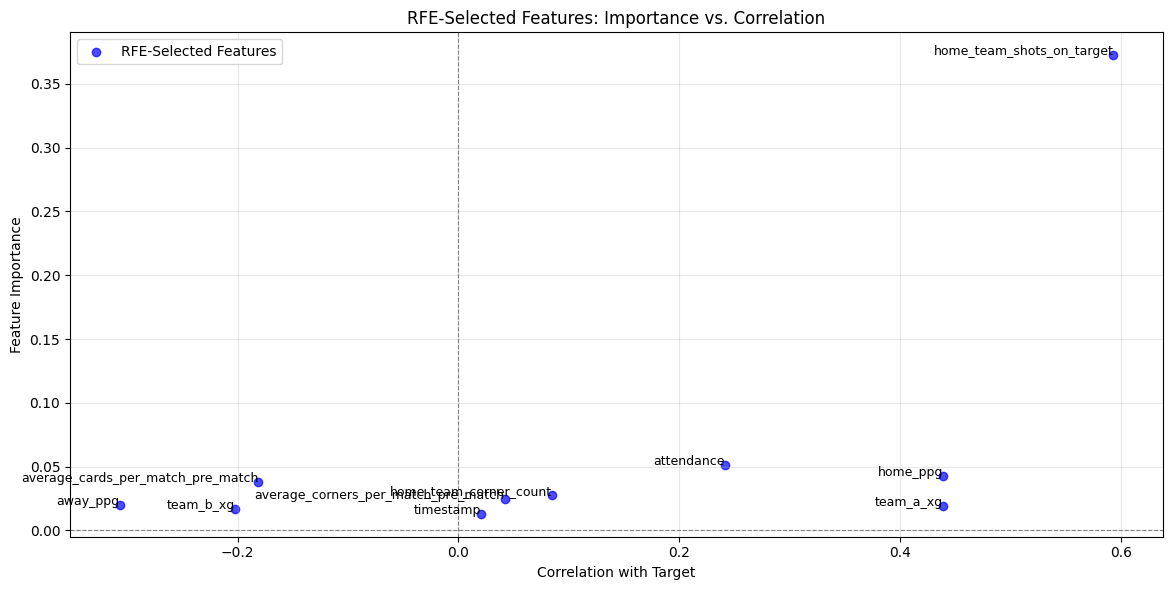

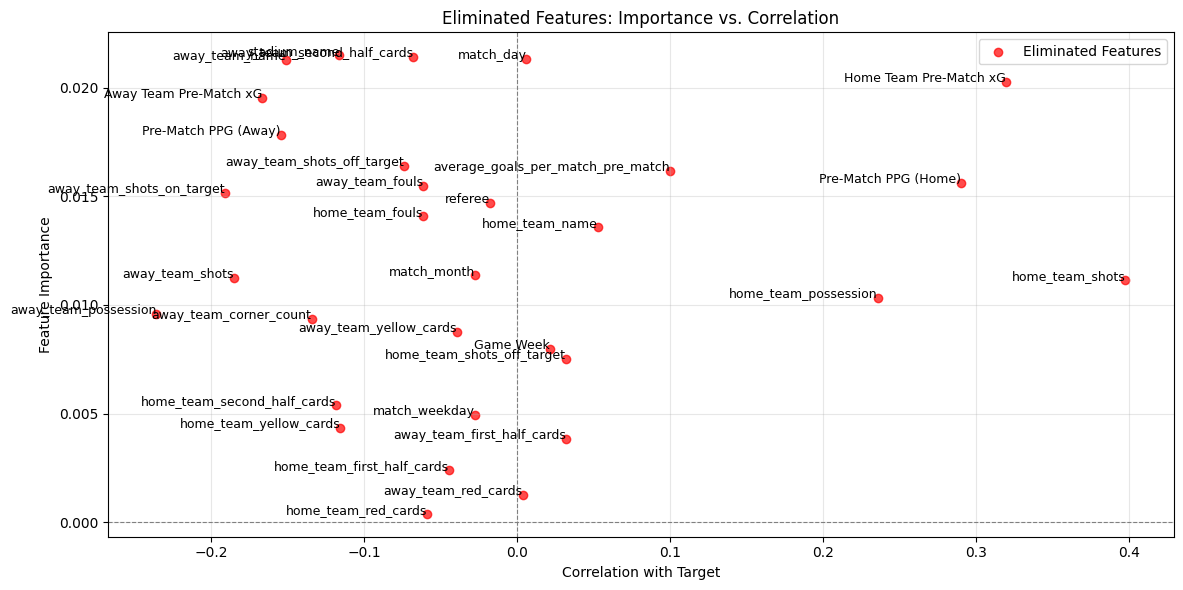

In [31]:
# Scatter Plot for RFE-Selected Features
plt.figure(figsize=(12, 6))
plt.scatter(
    selected_feature_importance['Correlation'], 
    selected_feature_importance['Importance'], 
    color='blue', 
    alpha=0.7, 
    label='RFE-Selected Features'
)
for i in range(len(selected_feature_importance)):
    plt.text(
        selected_feature_importance['Correlation'].iloc[i],
        selected_feature_importance['Importance'].iloc[i],
        selected_feature_importance['Feature'].iloc[i],
        fontsize=9,
        ha='right'
    )
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('RFE-Selected Features: Importance vs. Correlation')
plt.xlabel('Correlation with Target')
plt.ylabel('Feature Importance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Scatter Plot for Eliminated Features
plt.figure(figsize=(12, 6))
plt.scatter(
    eliminated_feature_importance['Correlation'], 
    eliminated_feature_importance['Importance'], 
    color='red', 
    alpha=0.7, 
    label='Eliminated Features'
)
for i in range(len(eliminated_feature_importance)):
    plt.text(
        eliminated_feature_importance['Correlation'].iloc[i],
        eliminated_feature_importance['Importance'].iloc[i],
        eliminated_feature_importance['Feature'].iloc[i],
        fontsize=9,
        ha='right'
    )
plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
plt.axvline(0, color='gray', linestyle='--', linewidth=0.8)
plt.title('Eliminated Features: Importance vs. Correlation')
plt.xlabel('Correlation with Target')
plt.ylabel('Feature Importance')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


Så kommer vi fram til en Final Feature Selection

In [126]:
df_final = df_filtered

df_final.sample(10)

,home_team_goal_count,away_team_goal_count,timestamp,attendance,home_team_name,away_team_name,referee,Game Week,Pre-Match PPG (Home),Pre-Match PPG (Away),...,Away Team Pre-Match xG,team_a_xg,team_b_xg,average_goals_per_match_pre_match,average_corners_per_match_pre_match,average_cards_per_match_pre_match,stadium_name,match_month,match_day,match_weekday
8,0,0,1534077000,30784,15,3,6,1,NaN,NaN,...,NaN,1.29,1.69,NaN,NaN,NaN,13,8,12,6
274,2,0,1551296700,27597,15,8,2,28,0.92,0.14,...,1.04,1.49,1.19,2.96,8.02,4.41,13,2,27,2
90,1,0,1540648800,30654,2,19,2,10,1.75,1.75,...,1.48,0.82,2.16,2.38,9.25,4.00,15,10,27,5
218,0,1,1547397000,80062,16,13,13,22,2.00,1.55,...,1.38,2.43,1.64,3.37,10.06,3.66,20,1,13,6
212,2,1,1547305200,19316,3,8,11,22,1.00,0.18,...,1.01,0.87,1.37,3.19,6.52,3.43,17,1,12,5
308,2,0,1553958000,31530,10,0,9,32,1.33,0.80,...,1.32,1.66,0.98,2.93,11.60,3.26,7,3,30,5
309,2,1,1553958000,74543,13,17,17,32,2.07,1.25,...,1.16,1.23,2.13,3.15,11.13,3.96,10,3,30,5
339,2,2,1555768800,59960,18,10,10,35,1.59,1.41,...,1.38,1.34,1.51,3.00,11.41,3.12,8,4,20,5
203,0,0,1546458300,40668,5,15,7,21,2.10,0.70,...,1.42,1.56,0.95,2.90,9.70,3.20,14,1,2,2
312,2,1,1554046200,53322,11,16,11,32,2.73,2.06,...,1.41,1.40,1.15,3.36,12.01,2.81,0,3,31,6


Så definere modellen her (gjerne endre på det som står)Defining the Model

In [127]:
Y = df_final[['home_team_goal_count', 'away_team_goal_count']]
X = df_final.drop(columns = ['home_team_goal_count', 'away_team_goal_count'])

Training the model

Evaluating The model

Keep track of changes/adjustments. What didnt work? Why didnt it work? How was it changed?

Data cleaning:
At first all features containing pre-match info were removed, however this can be very valuable and was changed to only 'Nan' the early and not representative values.

Feature selection: 
Feature selection is an iterative process, at the beginning all features thought to be useful were included. Random forrest models are used with feature importance. 

Evaluation: 
The evaluation can both look at how well the model predicts the amount of goals scored by home and away team, but also how often it predicts the coorect outcome of the game (HAD)
